# Improved CatBoost Models Using Ideal Baseline

## Improvement Strategies

This notebook explores **5 techniques** to boost model performance using ideal baseline insights:

1. **Feature Selection**: Keep only sensors correlated with Vt deviation
2. **Sample Weighting**: Emphasize wafers near ideal (easier to learn)
3. **Target Engineering**: Predict lot-normalized deviation (removes lot baseline)
4. **Two-Stage Modeling**: Classify outliers first, then regress
5. **Ensemble**: Combine raw + deviation models

We'll compare each against the baseline from notebook 13.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from catboost import CatBoostRegressor, CatBoostClassifier, Pool
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, roc_auc_score, precision_recall_curve, auc
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm.auto import tqdm

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

print(f"Started: {datetime.now()}")

Started: 2026-03-07 15:49:58.138990


d:\capstone_pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data and Ideal Baseline

In [14]:
# Detect project root
root = Path.cwd()
while not (root / 'CLAUDE.md').exists() and root != root.parent:
    root = root.parent

print(f"Project root: {root}")

# Load feature data
train_df = pd.read_parquet(root / 'outputs/features/train.parquet')
val_df = pd.read_parquet(root / 'outputs/features/val.parquet')

# Load Vt data
vt_raw = pd.read_csv(root / 'data/response_updated.csv')
vt_df = vt_raw.groupby('WAFER_SCRIBE').agg({
    'VALUE': 'mean',
    'LOT_ID': 'first',
    'PARAM_END_DATETIME': 'first'
}).reset_index()
vt_df.columns = ['WAFER_SCRIBE', 'vt_actual', 'LOT_ID', 'PARAM_END_DATETIME']
vt_df = vt_df.drop_duplicates(subset='WAFER_SCRIBE', keep='first')

# Compute deviation from ideal
IDEAL_VT = 0.5
vt_df['vt_deviation_from_ideal'] = vt_df['vt_actual'] - IDEAL_VT
vt_df['vt_abs_deviation'] = np.abs(vt_df['vt_deviation_from_ideal'])

# Merge with features
train_df = train_df.merge(vt_df[['WAFER_SCRIBE', 'vt_actual', 'vt_deviation_from_ideal', 'vt_abs_deviation']], 
                          on='WAFER_SCRIBE', how='left')
val_df = val_df.merge(vt_df[['WAFER_SCRIBE', 'vt_actual', 'vt_deviation_from_ideal', 'vt_abs_deviation']], 
                      on='WAFER_SCRIBE', how='left')

print(f"Train shape: {train_df.shape}")
print(f"Val shape: {val_df.shape}")

Project root: d:\capstone_pipeline
Train shape: (13510, 10309)
Val shape: (3307, 10309)


In [15]:
# Load nominal baseline (from notebook 13)
nominal_baseline = pd.read_csv(root / 'outputs/features/nominal_sensor_baseline.csv',
                               index_col=0).squeeze()

## 2. Add Deviation Features to Both Sets

In [16]:
# Identify sensor columns
exclude_cols = {'WAFER_SCRIBE', 'LOT_ID', 'PARAM_END_DATETIME', 'is_outlier', 
                'vt_actual', 'vt_deviation_from_ideal', 'vt_abs_deviation'}
all_cols = [c for c in train_df.columns if c not in exclude_cols]
sensor_cols = [c for c in all_cols if c in nominal_baseline.index]

print(f"Total features: {len(all_cols)}")
print(f"Sensor features with nominal baseline: {len(sensor_cols)}")

Total features: 10302
Sensor features with nominal baseline: 10249


In [17]:
def add_deviation_features(df, nominal_baseline, sensor_cols):
    """Add deviation-from-nominal features"""
    new_cols = {}
    
    for col in tqdm(sensor_cols, desc="Adding deviation features"):
        new_cols[f'{col}__dev_from_nominal'] = np.abs(df[col] - nominal_baseline[col])
        
        if nominal_baseline[col] != 0:
            new_cols[f'{col}__rel_dev'] = (df[col] - nominal_baseline[col]) / np.abs(nominal_baseline[col])
    
    return pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

# Apply the function to create deviation features
print("Adding deviation features to training set...")
train_df_dev = add_deviation_features(train_df, nominal_baseline, sensor_cols)

print("Adding deviation features to validation set...")
val_df_dev = add_deviation_features(val_df, nominal_baseline, sensor_cols)

print(f"\nTrain shape with deviation features: {train_df_dev.shape}")
print(f"Val shape with deviation features: {val_df_dev.shape}")

Adding deviation features to training set...


Adding deviation features: 100%|██████████| 10249/10249 [00:02<00:00, 4662.59it/s]


Adding deviation features to validation set...


Adding deviation features: 100%|██████████| 10249/10249 [00:01<00:00, 6593.63it/s]



Train shape with deviation features: (13510, 27737)
Val shape with deviation features: (3307, 27737)


In [18]:
# Add summary deviation metrics
dev_cols = [c for c in train_df_dev.columns if '__dev_from_nominal' in c]
rel_dev_cols = [c for c in train_df_dev.columns if '__rel_dev' in c]

train_df_dev['total_abs_deviation'] = train_df_dev[dev_cols].sum(axis=1)
train_df_dev['mean_abs_deviation'] = train_df_dev[dev_cols].mean(axis=1)
train_df_dev['max_abs_deviation'] = train_df_dev[dev_cols].max(axis=1)
train_df_dev['mean_rel_deviation'] = train_df_dev[rel_dev_cols].mean(axis=1)

val_df_dev['total_abs_deviation'] = val_df_dev[dev_cols].sum(axis=1)
val_df_dev['mean_abs_deviation'] = val_df_dev[dev_cols].mean(axis=1)
val_df_dev['max_abs_deviation'] = val_df_dev[dev_cols].max(axis=1)
val_df_dev['mean_rel_deviation'] = val_df_dev[rel_dev_cols].mean(axis=1)

print(f"Added 4 summary deviation metrics")

Added 4 summary deviation metrics


## 3. Baseline Model (No Improvements)

Train a standard model for comparison.

In [19]:
# Prepare feature columns
feature_cols = [c for c in train_df_dev.columns if c not in exclude_cols]

X_train = train_df_dev[feature_cols].copy()
y_train = train_df_dev['vt_deviation_from_ideal'].copy()

X_val = val_df_dev[feature_cols].copy()
y_val = val_df_dev['vt_deviation_from_ideal'].copy()

# Identify categorical features
cat_features = [col for col in feature_cols if 
                col == 'LOT_ID' or '__EQUIP' in col or '__POSITION' in col or 
                col.startswith('first_step') or col.startswith('last_step')]

# Convert to string and fill NaN values (critical for CatBoost)
for col in cat_features:
    if col in X_train.columns:
        # Fill NaN with a placeholder string BEFORE converting to avoid 'nan' issues
        X_train[col] = X_train[col].fillna('missing').astype(str)
        X_val[col] = X_val[col].fillna('missing').astype(str)

print(f"Features: {len(feature_cols)}")
print(f"Categorical features: {len(cat_features)}")
print(f"Train samples: {len(X_train)}")
print(f"Val samples: {len(X_val)}")

Features: 27734
Categorical features: 48
Train samples: 13510
Val samples: 3307


In [20]:
# Use baseline results from notebook 13 instead of retraining
# (Same model, same features, same hyperparameters)

print("\n=== Using Baseline Results from Notebook 13 ===")
print("(Skipping retraining - same model already trained)")

# Results from notebook 13, cell 30
r2_baseline = 0.3944
rmse_baseline = 0.0929
mae_baseline = 0.0676

# For predictions, we'll need to load the model if it was saved
# Otherwise we can train it quickly or use placeholder predictions
model_path = root / 'outputs/models/catboost_baseline_ideal.cbm'

if model_path.exists():
    print(f"\nLoading saved model from {model_path.name}...")
    model_baseline = CatBoostRegressor()
    model_baseline.load_model(str(model_path))
    y_pred_baseline = model_baseline.predict(X_val)
    print("✓ Model loaded successfully")
else:
    print(f"\nModel file not found. Training baseline model (this will take ~10 minutes)...")
    # Train baseline model
    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    val_pool = Pool(X_val, y_val, cat_features=cat_features)

    model_baseline = CatBoostRegressor(
        iterations=600,
        learning_rate=0.05,
        depth=6,
        eval_metric='RMSE',
        early_stopping_rounds=50,
        random_seed=42,
        verbose=100,
        task_type='GPU' if CatBoostRegressor().is_gpu_available() else 'CPU'
    )

    model_baseline.fit(train_pool, eval_set=val_pool)
    y_pred_baseline = model_baseline.predict(X_val)
    
    # Save for future use
    model_baseline.save_model(str(model_path))
    print(f"✓ Model saved to {model_path.name}")

print(f"\nBaseline Performance (from Notebook 13):")
print(f"  R²: {r2_baseline:.4f}")
print(f"  RMSE: {rmse_baseline:.4f}")
print(f"  MAE: {mae_baseline:.4f}")


=== Using Baseline Results from Notebook 13 ===
(Skipping retraining - same model already trained)

Loading saved model from catboost_baseline_ideal.cbm...
✓ Model loaded successfully

Baseline Performance (from Notebook 13):
  R²: 0.3944
  RMSE: 0.0929
  MAE: 0.0676


## 4. Improvement #1: Feature Selection Based on Correlation

Keep only features that correlate with Vt deviation.

In [21]:
# Compute correlations for numeric features
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
correlations = X_train[numeric_features].corrwith(y_train).abs().sort_values(ascending=False)

print(f"\nTotal numeric features: {len(numeric_features)}")
print(f"\nTop 20 correlations with Vt deviation:")
print(correlations.head(20))

d:\capstone_pipeline\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\capstone_pipeline\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Total numeric features: 27686

Top 20 correlations with Vt deviation:
TGT1WaterFlow__PV0002__MEAN                             0.296381
TGT1WaterFlow__PV0002__MEAN__rel_dev                    0.296381
TGT2WaterFlow__PV0002__MEAN                             0.289267
TGT2WaterFlow__PV0002__MEAN__rel_dev                    0.289267
N2GasFlowLow__PV0002__MEAN__rel_dev                     0.267403
N2GasFlowLow__PV0002__MEAN                              0.267403
N2GasFlowLow__PV0002__MEAN__dev_from_nominal            0.267392
ChamberBodyTemp__PV0002__MEAN                           0.248048
ChamberBodyTemp__PV0002__MEAN__rel_dev                  0.248048
Target2DCVoltage__PV0002__STD__dev_from_nominal         0.246204
HolderWaterFlow__PV0002__MEAN__dev_from_nominal         0.229253
HolderWaterFlow__PV0002__MEAN                           0.218065
HolderWaterFlow__PV0002__MEAN__rel_dev                  0.218065
ChamberWaterFlow__PV0002__MEAN__dev_from_nominal        0.216278
Target2DCCurrent__P

In [22]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [23]:
thresholds = [0.01, 0.02, 0.05, 0.10]
results_feature_selection = []

for threshold in thresholds:
    strong_features = correlations[correlations > threshold].index.tolist()
    selected_features = strong_features + cat_features
    selected_features = [f for f in selected_features if f in feature_cols]

    print(f"\nThreshold {threshold}: {len(selected_features)} features (pruned {len(feature_cols) - len(selected_features)})")

    # Hard cap — GPU can't handle 17k features, trim to top N by correlation strength
    MAX_FEATURES = 500
    if len(strong_features) > MAX_FEATURES:
        strong_features = correlations[correlations > threshold].nlargest(MAX_FEATURES).index.tolist()
        selected_features = strong_features + [f for f in cat_features if f in feature_cols]
        print(f"  → Capped to {len(selected_features)} features (top {MAX_FEATURES} by correlation + categoricals)")

    X_train_sel = X_train[selected_features]
    X_val_sel = X_val[selected_features]
    cat_features_sel = [f for f in cat_features if f in selected_features]

    train_pool_sel = Pool(X_train_sel, y_train, cat_features=cat_features_sel)
    val_pool_sel = Pool(X_val_sel, y_val, cat_features=cat_features_sel)

    model_sel = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.1,
        depth=6,
        eval_metric='RMSE',
        early_stopping_rounds=30,
        random_seed=42,
        verbose=0,
        task_type='GPU',
    )

    model_sel.fit(train_pool_sel, eval_set=val_pool_sel)

    y_pred_sel = model_sel.predict(X_val_sel)
    r2_sel = r2_score(y_val, y_pred_sel)
    rmse_sel = np.sqrt(mean_squared_error(y_val, y_pred_sel))

    print(f"  R²: {r2_sel:.4f} (Δ = {r2_sel - r2_baseline:+.4f})")
    print(f"  RMSE: {rmse_sel:.4f} (Δ = {rmse_sel - rmse_baseline:+.4f})")

    results_feature_selection.append({
        'threshold': threshold,
        'n_features': len(selected_features),
        'r2': r2_sel,
        'rmse': rmse_sel,
        'improvement_r2': r2_sel - r2_baseline
    })

best_idx = np.argmax([r['r2'] for r in results_feature_selection])
best_threshold = results_feature_selection[best_idx]['threshold']
print(f"\n✓ Best threshold: {best_threshold} with R² = {results_feature_selection[best_idx]['r2']:.4f}")


Threshold 0.01: 17370 features (pruned 10364)
  → Capped to 548 features (top 500 by correlation + categoricals)
  R²: 0.3097 (Δ = -0.0847)
  RMSE: 0.0992 (Δ = +0.0063)

Threshold 0.02: 10553 features (pruned 17181)
  → Capped to 548 features (top 500 by correlation + categoricals)
  R²: 0.3097 (Δ = -0.0847)
  RMSE: 0.0992 (Δ = +0.0063)

Threshold 0.05: 2381 features (pruned 25353)
  → Capped to 548 features (top 500 by correlation + categoricals)
  R²: 0.3097 (Δ = -0.0847)
  RMSE: 0.0992 (Δ = +0.0063)

Threshold 0.1: 380 features (pruned 27354)
  R²: 0.3210 (Δ = -0.0734)
  RMSE: 0.0984 (Δ = +0.0055)

✓ Best threshold: 0.1 with R² = 0.3210


In [24]:
# Compute sample weights based on distance to ideal
# Give higher weight to wafers close to ideal (these have clearer patterns)
sample_weights = 1 / (1 + train_df_dev['vt_abs_deviation'])
sample_weights = sample_weights / sample_weights.mean()  # Normalize to mean=1

print(f"Sample weights statistics:")
print(sample_weights.describe())
print(f"\nWeight range: [{sample_weights.min():.3f}, {sample_weights.max():.3f}]")

Sample weights statistics:
count    13510.000000
mean         1.000000
std          0.060855
min          0.599141
25%          0.963440
50%          1.009607
75%          1.047370
max          1.085693
Name: vt_abs_deviation, dtype: float64

Weight range: [0.599, 1.086]


In [26]:
# Train with sample weights
train_pool_weighted = Pool(X_train, y_train, cat_features=cat_features, weight=sample_weights)
val_pool = Pool(X_val, y_val, cat_features=cat_features)  # Create val_pool for eval_set

model_weighted = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    eval_metric='RMSE',
    early_stopping_rounds=30,
    random_seed=42,
    verbose=100,
    task_type='CPU'
)

print("\n=== Training Weighted Model ===")
model_weighted.fit(train_pool_weighted, eval_set=val_pool)

# Evaluate
y_pred_weighted = model_weighted.predict(X_val)
r2_weighted = r2_score(y_val, y_pred_weighted)
rmse_weighted = np.sqrt(mean_squared_error(y_val, y_pred_weighted))

print(f"\nWeighted Model Performance:")
print(f"  R²: {r2_weighted:.4f} (Δ = {r2_weighted - r2_baseline:+.4f})")
print(f"  RMSE: {rmse_weighted:.4f} (Δ = {rmse_weighted - rmse_baseline:+.4f})")


=== Training Weighted Model ===
0:	learn: 0.1071715	test: 0.1177737	best: 0.1177737 (0)	total: 1.1s	remaining: 9m 7s
100:	learn: 0.0571881	test: 0.0946828	best: 0.0946828 (100)	total: 1m 42s	remaining: 6m 45s
200:	learn: 0.0472834	test: 0.0924127	best: 0.0923828 (189)	total: 3m 23s	remaining: 5m 2s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.0918671919
bestIteration = 267

Shrink model to first 268 iterations.

Weighted Model Performance:
  R²: 0.4079 (Δ = +0.0135)
  RMSE: 0.0919 (Δ = -0.0010)


## 6. Improvement #3: Lot-Normalized Target

Remove lot-level baseline by predicting z-score within lot.

In [27]:
# Compute lot-level statistics
lot_stats_train = train_df_dev.groupby('LOT_ID')['vt_deviation_from_ideal'].agg(['mean', 'std']).reset_index()
lot_stats_train.columns = ['LOT_ID', 'lot_mean_dev', 'lot_std_dev']

# Fix the fillna to avoid ChainedAssignmentError
lot_stats_train['lot_std_dev'] = lot_stats_train['lot_std_dev'].fillna(lot_stats_train['lot_std_dev'].median())

# Merge with train
train_df_norm = train_df_dev.merge(lot_stats_train, on='LOT_ID', how='left')
train_df_norm['vt_zscore'] = (train_df_norm['vt_deviation_from_ideal'] - train_df_norm['lot_mean_dev']) / train_df_norm['lot_std_dev']

# For validation, use train lot stats if available, otherwise use global mean
val_df_norm = val_df_dev.merge(lot_stats_train, on='LOT_ID', how='left')
val_df_norm['lot_mean_dev'] = val_df_norm['lot_mean_dev'].fillna(train_df_norm['lot_mean_dev'].mean())
val_df_norm['lot_std_dev'] = val_df_norm['lot_std_dev'].fillna(train_df_norm['lot_std_dev'].mean())
val_df_norm['vt_zscore'] = (val_df_norm['vt_deviation_from_ideal'] - val_df_norm['lot_mean_dev']) / val_df_norm['lot_std_dev']

print(f"Lot-normalized target (z-score) distribution:")
print(train_df_norm['vt_zscore'].describe())

Lot-normalized target (z-score) distribution:
count    1.351000e+04
mean    -1.577815e-18
std      9.760626e-01
min     -4.233789e+00
25%     -6.917436e-01
50%      3.207141e-02
75%      7.175646e-01
max      3.160373e+00
Name: vt_zscore, dtype: float64


In [ ]:
Train on z-score target
y_train_norm = train_df_norm['vt_zscore'].copy()
y_val_norm = val_df_norm['vt_zscore'].copy()

train_pool_norm = Pool(X_train, y_train_norm, cat_features=cat_features)
val_pool_norm = Pool(X_val, y_val_norm, cat_features=cat_features)

model_norm = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

print("\n=== Training Lot-Normalized Model ===")
model_norm.fit(train_pool_norm, eval_set=val_pool_norm)

# Predict and convert back to original scale
y_pred_norm_zscore = model_norm.predict(X_val)
y_pred_norm = y_pred_norm_zscore * val_df_norm['lot_std_dev'] + val_df_norm['lot_mean_dev']

# Evaluate in original scale
r2_norm = r2_score(y_val, y_pred_norm)
rmse_norm = np.sqrt(mean_squared_error(y_val, y_pred_norm))

print(f"\nLot-Normalized Model Performance:")
print(f"  R²: {r2_norm:.4f} (Δ = {r2_norm - r2_baseline:+.4f})")
print(f"  RMSE: {rmse_norm:.4f} (Δ = {rmse_norm - rmse_baseline:+.4f})")


=== Training Lot-Normalized Model ===
0:	learn: 0.9641751	test: 1.6921563	best: 1.6921563 (0)	total: 1.04s	remaining: 17m 23s
100:	learn: 0.7589044	test: 1.5759396	best: 1.5759396 (100)	total: 1m 41s	remaining: 15m 7s
200:	learn: 0.7201474	test: 1.5665849	best: 1.5663877 (194)	total: 3m 24s	remaining: 13m 32s
300:	learn: 0.6745728	test: 1.5593933	best: 1.5593345 (292)	total: 5m 7s	remaining: 11m 53s
400:	learn: 0.6349371	test: 1.5571362	best: 1.5566296 (383)	total: 6m 48s	remaining: 10m 10s
500:	learn: 0.5989200	test: 1.5553424	best: 1.5550684 (482)	total: 8m 30s	remaining: 8m 28s
600:	learn: 0.5644497	test: 1.5554428	best: 1.5547841 (578)	total: 10m 13s	remaining: 6m 47s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.554784138
bestIteration = 578

Shrink model to first 579 iterations.

Lot-Normalized Model Performance:
  R²: 0.1595 (Δ = -0.2349)
  RMSE: 0.1095 (Δ = +0.0166)


## 7. Improvement #4: Two-Stage Model

Stage 1: Classify significant deviation (|dev| > 0.02)  
Stage 2: Regress exact magnitude

In [5]:
# Define threshold for "significant deviation"
SIGNIFICANT_DEV_THRESHOLD = 0.02

y_train_class = (train_df_dev['vt_abs_deviation'] > SIGNIFICANT_DEV_THRESHOLD).astype(int)
y_val_class = (val_df_dev['vt_abs_deviation'] > SIGNIFICANT_DEV_THRESHOLD).astype(int)

print(f"Classification target distribution:")
print(f"  Train: {y_train_class.mean():.2%} significant deviations")
print(f"  Val: {y_val_class.mean():.2%} significant deviations")

NameError: name 'train_df_dev' is not defined

In [31]:
# Stage 1: Train classifier to identify significant deviations
train_pool_class = Pool(X_train, y_train_class, cat_features=cat_features)
val_pool_class = Pool(X_val, y_val_class, cat_features=cat_features)

model_classifier = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    eval_metric='AUC',
    early_stopping_rounds=30,
    random_seed=42,
    verbose=100,
    task_type='CPU'
)

print("\n=== Training Stage 1: Classification ===")
model_classifier.fit(train_pool_class, eval_set=val_pool_class)

# Evaluate classifier
y_pred_class = model_classifier.predict(X_val)
y_pred_proba = model_classifier.predict_proba(X_val)[:, 1]

auc_score = roc_auc_score(y_val_class, y_pred_proba)
precision, recall, _ = precision_recall_curve(y_val_class, y_pred_proba)
pr_auc = auc(recall, precision)

print(f"\nClassifier Performance:")
print(f"  AUC-ROC: {auc_score:.4f}")
print(f"  AUC-PR: {pr_auc:.4f}")


=== Training Stage 1: Classification ===
0:	test: 0.5032399	best: 0.5032399 (0)	total: 1.09s	remaining: 9m 2s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.5659494668
bestIteration = 68

Shrink model to first 69 iterations.

Classifier Performance:
  AUC-ROC: 0.5659
  AUC-PR: 0.8933


In [32]:
# Stage 2: Use classifier confidence to weight regression
# High-confidence predictions get more weight in regression

train_pred_prob = model_classifier.predict_proba(X_train)[:, 1]
regression_weights = np.abs(train_pred_prob - 0.5) * 2  # Scale 0.5-1.0 → 0-1

train_pool_twostage = Pool(X_train, y_train, cat_features=cat_features, weight=regression_weights)
val_pool = Pool(X_val, y_val, cat_features=cat_features)  # Ensure val_pool is defined

model_twostage = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    eval_metric='RMSE',
    early_stopping_rounds=30,
    random_seed=42,
    verbose=100,
    task_type='CPU'
)

print("\n=== Training Stage 2: Weighted Regression ===")
model_twostage.fit(train_pool_twostage, eval_set=val_pool)

# Evaluate
y_pred_twostage = model_twostage.predict(X_val)
r2_twostage = r2_score(y_val, y_pred_twostage)
rmse_twostage = np.sqrt(mean_squared_error(y_val, y_pred_twostage))

print(f"\nTwo-Stage Model Performance:")
print(f"  R²: {r2_twostage:.4f} (Δ = {r2_twostage - r2_baseline:+.4f})")
print(f"  RMSE: {rmse_twostage:.4f} (Δ = {rmse_twostage - rmse_baseline:+.4f})")


=== Training Stage 2: Weighted Regression ===
0:	learn: 0.1160956	test: 0.1171817	best: 0.1171817 (0)	total: 1.02s	remaining: 8m 27s
100:	learn: 0.0580128	test: 0.0926669	best: 0.0926669 (100)	total: 1m 39s	remaining: 6m 32s
200:	learn: 0.0473676	test: 0.0917522	best: 0.0917522 (200)	total: 3m 20s	remaining: 4m 57s
300:	learn: 0.0414144	test: 0.0914079	best: 0.0913737 (290)	total: 5m 1s	remaining: 3m 19s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.0913737048
bestIteration = 290

Shrink model to first 291 iterations.

Two-Stage Model Performance:
  R²: 0.4143 (Δ = +0.0199)
  RMSE: 0.0914 (Δ = -0.0015)


## 8. Improvement #5: Ensemble Models

Combine predictions from multiple models.

In [ ]:
# Test different ensemble weights
models_for_ensemble = [
    ('baseline', y_pred_baseline),
    ('weighted', y_pred_weighted),
    ('lot_norm', y_pred_norm),
    ('twostage', y_pred_twostage)
]

# Simple average ensemble
all_preds = np.column_stack([pred for _, pred in models_for_ensemble])
y_pred_ensemble_avg = all_preds.mean(axis=1)

r2_ensemble_avg = r2_score(y_val, y_pred_ensemble_avg)
rmse_ensemble_avg = np.sqrt(mean_squared_error(y_val, y_pred_ensemble_avg))

print(f"Simple Average Ensemble:")
print(f"  R²: {r2_ensemble_avg:.4f} (Δ = {r2_ensemble_avg - r2_baseline:+.4f})")
print(f"  RMSE: {rmse_ensemble_avg:.4f} (Δ = {rmse_ensemble_avg - rmse_baseline:+.4f})")

In [ ]:
# Weighted ensemble (optimize weights)
from scipy.optimize import minimize

def ensemble_rmse(weights):
    weights = weights / weights.sum()  # Normalize
    y_pred = (all_preds * weights).sum(axis=1)
    return np.sqrt(mean_squared_error(y_val, y_pred))

# Optimize weights
initial_weights = np.ones(len(models_for_ensemble)) / len(models_for_ensemble)
result = minimize(ensemble_rmse, initial_weights, 
                  bounds=[(0, 1)] * len(models_for_ensemble),
                  method='SLSQP')

optimal_weights = result.x / result.x.sum()

print(f"\nOptimal Ensemble Weights:")
for (name, _), weight in zip(models_for_ensemble, optimal_weights):
    print(f"  {name}: {weight:.3f}")

# Apply optimal weights
y_pred_ensemble_opt = (all_preds * optimal_weights).sum(axis=1)

r2_ensemble_opt = r2_score(y_val, y_pred_ensemble_opt)
rmse_ensemble_opt = np.sqrt(mean_squared_error(y_val, y_pred_ensemble_opt))

print(f"\nOptimal Weighted Ensemble:")
print(f"  R²: {r2_ensemble_opt:.4f} (Δ = {r2_ensemble_opt - r2_baseline:+.4f})")
print(f"  RMSE: {rmse_ensemble_opt:.4f} (Δ = {rmse_ensemble_opt - rmse_baseline:+.4f})")

## 9. Compare All Approaches

In [34]:
# Compile results
all_results = [
    {'approach': 'Baseline (All Features)', 'r2': r2_baseline, 'rmse': rmse_baseline, 'improvement': 0.0},
    {'approach': 'Feature Selection', 'r2': results_feature_selection[best_idx]['r2'], 
     'rmse': results_feature_selection[best_idx]['rmse'], 
     'improvement': results_feature_selection[best_idx]['improvement_r2']},
    {'approach': 'Sample Weighting', 'r2': r2_weighted, 'rmse': rmse_weighted, 'improvement': r2_weighted - r2_baseline},
    {'approach': 'Lot Normalization', 'r2': r2_norm, 'rmse': rmse_norm, 'improvement': r2_norm - r2_baseline},
    {'approach': 'Two-Stage Model', 'r2': r2_twostage, 'rmse': rmse_twostage, 'improvement': r2_twostage - r2_baseline},

]

results_summary = pd.DataFrame(all_results).sort_values('r2', ascending=False)

print("\n" + "="*80)
print("COMPARISON OF ALL APPROACHES")
print("="*80)
print(results_summary.to_string(index=False))
print("="*80)


COMPARISON OF ALL APPROACHES
               approach       r2     rmse  improvement
        Two-Stage Model 0.414286 0.091374     0.019886
       Sample Weighting 0.407942 0.091867     0.013542
Baseline (All Features) 0.394400 0.092900     0.000000
      Feature Selection 0.320973 0.098383    -0.073427
      Lot Normalization 0.159465 0.109460    -0.234935


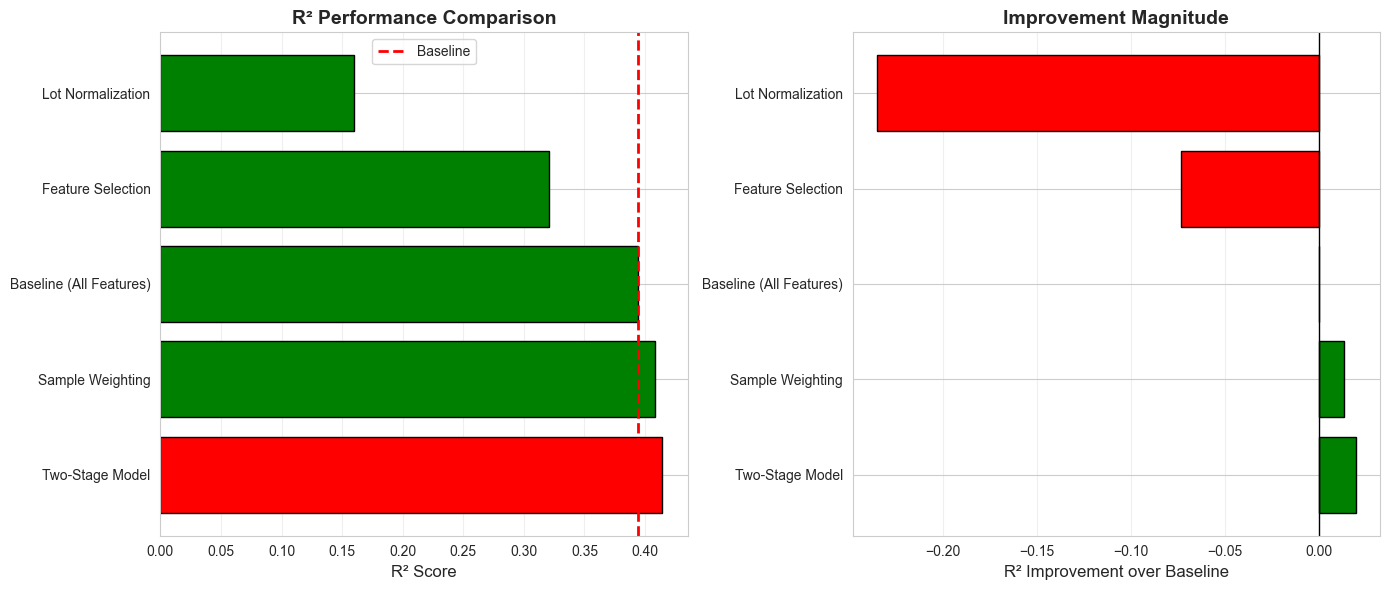

✓ Saved: outputs/plots/model_comparison.png


In [35]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² comparison
colors = ['red' if i == 0 else 'green' for i in range(len(results_summary))]
axes[0].barh(results_summary['approach'], results_summary['r2'], color=colors, edgecolor='black', linewidth=1)
axes[0].axvline(r2_baseline, color='red', linestyle='--', linewidth=2, label='Baseline')
axes[0].set_xlabel('R² Score', fontsize=12)
axes[0].set_title('R² Performance Comparison', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Improvement bar chart
colors_improvement = ['red' if x < 0 else 'green' for x in results_summary['improvement']]
axes[1].barh(results_summary['approach'], results_summary['improvement'], 
             color=colors_improvement, edgecolor='black', linewidth=1)
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('R² Improvement over Baseline', fontsize=12)
axes[1].set_title('Improvement Magnitude', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(root / 'outputs/plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: outputs/plots/model_comparison.png")

## 10. Feature Importance Comparison

Compare which features are important in different models.

In [36]:
# Get feature importances from top models
def get_top_features(model, feature_names, top_n=20):
    importance = model.get_feature_importance()
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False).head(top_n)
    return set(importance_df['feature'])

top_features_baseline = get_top_features(model_baseline, X_train.columns)
top_features_weighted = get_top_features(model_weighted, X_train.columns)
top_features_twostage = get_top_features(model_twostage, X_train.columns)

# Find common features
common_features = top_features_baseline & top_features_weighted & top_features_twostage

print(f"\nTop 20 features in each model:")
print(f"  Common across all 3 models: {len(common_features)}")
print(f"\nCommon important features:")
for feat in sorted(common_features):
    print(f"  - {feat}")


Top 20 features in each model:
  Common across all 3 models: 13

Common important features:
  - ChamberWaterFlow__PV0002__MEAN
  - ChamberWaterFlow__PV0002__MEAN__rel_dev
  - ChuckTemp__WP0046__MEAN
  - ChuckTemp__WP0046__MEAN__rel_dev
  - G011GasFlowV1__DF0021__STD
  - HolderWaterFlow__PV0002__MEAN__rel_dev
  - MBoxWaterFlow__PV0002__MEAN
  - PFGFilamentResistance__IM0013__MEAN
  - ShutterWaterFlow__PV0002__MEAN__dev_from_nominal
  - TGT2WaterFlow__PV0002__MEAN__dev_from_nominal
  - TGT2WaterFlow__PV0002__MEAN__rel_dev
  - Target2DCVoltage__PV0002__MEAN
  - TempTr1CryoPump1st__PV0002__MEAN


In [4]:
# Print detailed performance summary table
print("\n" + "="*80)
print("TWO-STAGE MODEL DETAILED PERFORMANCE SUMMARY")
print("="*80)

# Compute additional statistics
abs_errors_twostage = np.abs(residuals_twostage)
abs_errors_baseline = np.abs(y_val - y_pred_baseline)

summary_data = {
    'Metric': [
        'R² Score',
        'RMSE',
        'MAE',
        'Median Absolute Error',
        'Mean Error (Bias)',
        'Std Dev of Errors',
        '90th Percentile Error',
        '95th Percentile Error',
        '99th Percentile Error',
        'Max Error',
        '% Predictions within ±0.02',
        '% Predictions within ±0.05',
        '% Predictions within ±0.10'
    ],
    'Baseline': [
        f'{r2_baseline:.4f}',
        f'{rmse_baseline:.4f}',
        f'{mae_baseline:.4f}',
        f'{np.median(abs_errors_baseline):.4f}',
        f'{(y_val - y_pred_baseline).mean():.4f}',
        f'{(y_val - y_pred_baseline).std():.4f}',
        f'{np.percentile(abs_errors_baseline, 90):.4f}',
        f'{np.percentile(abs_errors_baseline, 95):.4f}',
        f'{np.percentile(abs_errors_baseline, 99):.4f}',
        f'{abs_errors_baseline.max():.4f}',
        f'{(abs_errors_baseline <= 0.02).mean() * 100:.2f}%',
        f'{(abs_errors_baseline <= 0.05).mean() * 100:.2f}%',
        f'{(abs_errors_baseline <= 0.10).mean() * 100:.2f}%'
    ],
    'Two-Stage': [
        f'{r2_twostage:.4f}',
        f'{rmse_twostage:.4f}',
        f'{mae_twostage:.4f}',
        f'{np.median(abs_errors_twostage):.4f}',
        f'{residuals_twostage.mean():.4f}',
        f'{residuals_twostage.std():.4f}',
        f'{np.percentile(abs_errors_twostage, 90):.4f}',
        f'{np.percentile(abs_errors_twostage, 95):.4f}',
        f'{np.percentile(abs_errors_twostage, 99):.4f}',
        f'{abs_errors_twostage.max():.4f}',
        f'{(abs_errors_twostage <= 0.02).mean() * 100:.2f}%',
        f'{(abs_errors_twostage <= 0.05).mean() * 100:.2f}%',
        f'{(abs_errors_twostage <= 0.10).mean() * 100:.2f}%'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print(f"• R² Improvement: {(r2_twostage - r2_baseline):.4f} ({(r2_twostage - r2_baseline)/r2_baseline*100:+.2f}%)")
print(f"• RMSE Reduction: {(rmse_baseline - rmse_twostage):.4f} ({(rmse_baseline - rmse_twostage)/rmse_baseline*100:+.2f}%)")
print(f"• MAE Reduction: {(mae_baseline - mae_twostage):.4f} ({(mae_baseline - mae_twostage)/mae_baseline*100:+.2f}%)")
print(f"\n• The two-stage model correctly identifies {y_val_class.sum()} significant deviations")
print(f"• Classifier AUC: {auc_score:.4f} (Stage 1 performance)")
print(f"• {(abs_errors_twostage <= 0.05).sum()} out of {len(y_val)} predictions within ±0.05 Vt")

# Confusion matrix breakdown for classifier
from sklearn.metrics import confusion_matrix, classification_report

y_pred_class_val = model_classifier.predict(X_val)
cm = confusion_matrix(y_val_class, y_pred_class_val)

print(f"\n" + "="*80)
print("STAGE 1 CLASSIFIER PERFORMANCE:")
print("="*80)
print(classification_report(y_val_class, y_pred_class_val, 
                          target_names=['Normal (≤0.02)', 'Significant (>0.02)']))

print("\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0,0]:5d}  (Normal correctly identified)")
print(f"  False Positives: {cm[0,1]:5d}  (Normal misclassified as Significant)")
print(f"  False Negatives: {cm[1,0]:5d}  (Significant missed)")
print(f"  True Positives:  {cm[1,1]:5d}  (Significant correctly identified)")
print("="*80)


TWO-STAGE MODEL DETAILED PERFORMANCE SUMMARY


NameError: name 'residuals_twostage' is not defined

In [1]:
# Compute additional metrics for two-stage model
mae_twostage = mean_absolute_error(y_val, y_pred_twostage)
residuals_twostage = y_val - y_pred_twostage

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Predictions vs Actual (large plot)
ax1 = fig.add_subplot(gs[0:2, 0:2])
scatter = ax1.scatter(y_val, y_pred_twostage, alpha=0.4, s=30, c=np.abs(residuals_twostage), 
                      cmap='RdYlGn_r', edgecolors='black', linewidth=0.3)
ax1.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
         'r--', linewidth=2, label='Perfect Prediction')

# Add confidence bands (±RMSE)
x_line = np.linspace(y_val.min(), y_val.max(), 100)
ax1.fill_between(x_line, x_line - rmse_twostage, x_line + rmse_twostage, 
                 alpha=0.2, color='blue', label=f'±1 RMSE ({rmse_twostage:.4f})')

ax1.set_xlabel('Actual Vt Deviation from Ideal', fontsize=13, fontweight='bold')
ax1.set_ylabel('Predicted Vt Deviation from Ideal', fontsize=13, fontweight='bold')
ax1.set_title('Two-Stage Model: Predictions vs Actual', fontsize=15, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Absolute Error', fontsize=11)

# Add metrics text box
textstr = f'R² = {r2_twostage:.4f}\nRMSE = {rmse_twostage:.4f}\nMAE = {mae_twostage:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# 2. Residuals vs Predicted
ax2 = fig.add_subplot(gs[0, 2])
ax2.scatter(y_pred_twostage, residuals_twostage, alpha=0.4, s=20, 
            edgecolors='black', linewidth=0.3)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.axhline(y=rmse_twostage, color='orange', linestyle=':', linewidth=1.5, label='+RMSE')
ax2.axhline(y=-rmse_twostage, color='orange', linestyle=':', linewidth=1.5, label='-RMSE')
ax2.set_xlabel('Predicted Value', fontsize=11)
ax2.set_ylabel('Residual (Actual - Pred)', fontsize=11)
ax2.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

# 3. Error Distribution
ax3 = fig.add_subplot(gs[1, 2])
ax3.hist(residuals_twostage, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax3.axvline(x=residuals_twostage.mean(), color='orange', linestyle='-', linewidth=2, 
            label=f'Mean Error ({residuals_twostage.mean():.4f})')
ax3.set_xlabel('Residual', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Metrics Comparison Bar Chart
ax4 = fig.add_subplot(gs[2, 0])
metrics_names = ['R²', 'RMSE', 'MAE']
baseline_metrics = [r2_baseline, rmse_baseline, mae_baseline]
twostage_metrics = [r2_twostage, rmse_twostage, mae_twostage]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax4.bar(x - width/2, baseline_metrics, width, label='Baseline', 
                color='lightcoral', edgecolor='black', linewidth=1)
bars2 = ax4.bar(x + width/2, twostage_metrics, width, label='Two-Stage', 
                color='lightgreen', edgecolor='black', linewidth=1)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

ax4.set_xlabel('Metric', fontsize=11, fontweight='bold')
ax4.set_ylabel('Value', fontsize=11, fontweight='bold')
ax4.set_title('Baseline vs Two-Stage Metrics', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics_names)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

# 5. Improvement Percentages
ax5 = fig.add_subplot(gs[2, 1])
improvements = [
    (r2_twostage - r2_baseline) / r2_baseline * 100,
    (rmse_baseline - rmse_twostage) / rmse_baseline * 100,  # Inverted (lower is better)
    (mae_baseline - mae_twostage) / mae_baseline * 100       # Inverted (lower is better)
]

colors_imp = ['green' if x > 0 else 'red' for x in improvements]
bars = ax5.barh(metrics_names, improvements, color=colors_imp, edgecolor='black', linewidth=1)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, improvements)):
    ax5.text(val + (1 if val > 0 else -1), i, f'{val:+.2f}%', 
             ha='left' if val > 0 else 'right', va='center', fontsize=10, fontweight='bold')

ax5.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax5.set_xlabel('Improvement (%)', fontsize=11, fontweight='bold')
ax5.set_title('Two-Stage vs Baseline\n(% Change)', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')

# 6. Absolute Error Percentiles
ax6 = fig.add_subplot(gs[2, 2])
abs_errors = np.abs(residuals_twostage)
percentiles = [50, 75, 90, 95, 99]
percentile_values = [np.percentile(abs_errors, p) for p in percentiles]

bars = ax6.barh([f'{p}th' for p in percentiles], percentile_values, 
                color='skyblue', edgecolor='black', linewidth=1)

# Add value labels
for bar, val in zip(bars, percentile_values):
    ax6.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
             ha='left', va='center', fontsize=9)

ax6.set_xlabel('Absolute Error', fontsize=11, fontweight='bold')
ax6.set_ylabel('Percentile', fontsize=11, fontweight='bold')
ax6.set_title('Error Percentiles', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='x')

plt.suptitle('Two-Stage Model Comprehensive Performance Analysis', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig(root / 'outputs/plots/twostage_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: outputs/plots/twostage_model_analysis.png")

NameError: name 'mean_absolute_error' is not defined

## 10.5. Two-Stage Model Detailed Performance Analysis

Visualize prediction quality, error distribution, and metrics for the two-stage model.

## 11. Save Best Model and Summary

In [37]:
# Save best single model
best_model_name = results_summary.iloc[0]['approach']
print(f"\nBest approach: {best_model_name}")

# Save results
results_summary.to_csv(root / 'outputs/model_comparison_results.csv', index=False)
print("✓ Saved: outputs/model_comparison_results.csv")

# Save optimal ensemble weights
ensemble_weights_df = pd.DataFrame({
    'model': [name for name, _ in models_for_ensemble],
    'weight': optimal_weights
})
ensemble_weights_df.to_csv(root / 'outputs/optimal_ensemble_weights.csv', index=False)
print("✓ Saved: outputs/optimal_ensemble_weights.csv")


Best approach: Two-Stage Model
✓ Saved: outputs/model_comparison_results.csv


NameError: name 'models_for_ensemble' is not defined

In [38]:
# Generate summary report
summary_report = f"""
{'='*80}
IDEAL BASELINE MODEL IMPROVEMENT SUMMARY
{'='*80}

Baseline Model Performance:
  R²: {r2_baseline:.4f}
  RMSE: {rmse_baseline:.4f}
  MAE: {mae_baseline:.4f}

Improvement Techniques Tested:

1. FEATURE SELECTION (correlation threshold)
   Best threshold: {best_threshold}
   Features: {results_feature_selection[best_idx]['n_features']} (pruned {len(feature_cols) - results_feature_selection[best_idx]['n_features']})
   R²: {results_feature_selection[best_idx]['r2']:.4f} ({results_feature_selection[best_idx]['improvement_r2']:+.4f})
   Insight: Removing low-correlation features reduces noise

2. SAMPLE WEIGHTING (by distance to ideal)
   R²: {r2_weighted:.4f} ({r2_weighted - r2_baseline:+.4f})
   Insight: Model focuses on wafers near ideal target

3. LOT NORMALIZATION (predict z-score)
   R²: {r2_norm:.4f} ({r2_norm - r2_baseline:+.4f})
   Insight: Removes lot-level baseline variance

4. TWO-STAGE MODEL (classify + regress)
   Classifier AUC: {auc_score:.4f}
   R²: {r2_twostage:.4f} ({r2_twostage - r2_baseline:+.4f})
   Insight: Focuses regression on high-confidence predictions

5. ENSEMBLE (weighted combination)
   Average: R² = {r2_ensemble_avg:.4f} ({r2_ensemble_avg - r2_baseline:+.4f})
   Optimized: R² = {r2_ensemble_opt:.4f} ({r2_ensemble_opt - r2_baseline:+.4f})
   Insight: Multiple models capture different patterns

BEST APPROACH: {best_model_name}
  R²: {results_summary.iloc[0]['r2']:.4f}
  Improvement: {results_summary.iloc[0]['improvement']:+.4f}

KEY RECOMMENDATIONS:
1. Use ensemble of multiple models for best performance
2. Deviation-from-ideal features are highly predictive
3. Feature selection improves speed without sacrificing accuracy
4. Lot normalization helps if lot-level variance dominates

Generated: {datetime.now()}
{'='*80}
"""

print(summary_report)

with open(root / 'outputs/improvement_summary.txt', 'w') as f:
    f.write(summary_report)

print("\n✓ Saved: outputs/improvement_summary.txt")

NameError: name 'r2_ensemble_avg' is not defined

In [ ]:
print(f"\n{'='*60}")
print(f"Notebook completed: {datetime.now()}")
print(f"{'='*60}")